In [193]:
from pathlib import Path
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

## Configurazione e selezione città

In [194]:
def classify_transformation_type(variant: str) -> str:
    """Classifica il tipo di trasformazione dalla variante."""
    variant_lower = variant.lower()
    if variant_lower == 'original':
        return 'original'
    elif 'rot' in variant_lower and 'rotation' not in variant_lower:
        return 'rotation'
    elif 'trans' in variant_lower or 'translation' in variant_lower:
        return 'translation'
    elif 'scale' in variant_lower or 'scal' in variant_lower:
        return 'scale'
    else:
        return 'other'

def load_all_results(city: str, source_filter: str = "all", exclude_scale: bool = True) -> pd.DataFrame:
    csv_paths = find_result_csvs(city, source_filter)
    print(f'\nCaricamento di {len(csv_paths)} file CSV...\n')
    all_data = []
    
    for csv_path in csv_paths:
        print(f"Carico: {csv_path.name}")
        df = pd.read_csv(csv_path)
        
        # Normalizza formato
        try:
            df = normalize_csv_format(df, csv_path.name)
        except ValueError as e:
            print(f"  ⚠ Skip: {e}")
            continue
        
        # Rimuovi duplicati
        df = remove_duplicate_variants(df)
        
        # Aggiungi colonne di metadata
        if 'total_work' not in df.columns:
            df['total_work'] = df['work_wd'] + df['work_hol']
        df['city'] = city
        df['source_file'] = str(csv_path.relative_to(BASE_DIR))
        df['source_folder'] = csv_path.parent.name
        
        print(f"  ✓ Caricati {len(df)} record da {csv_path.parent.name}")
        all_data.append(df)
    
    if not all_data:
        raise ValueError(f'Nessun CSV valido trovato per {city}')
    
    combined = pd.concat(all_data, ignore_index=True)
    
    # Aggiungi colonna tipo trasformazione
    combined['transformation_type'] = combined['variant'].apply(classify_transformation_type)
    
    # Filtra scale se richiesto
    if exclude_scale:
        before = len(combined)
        combined = combined[combined['transformation_type'] != 'scale'].copy()
        removed = before - len(combined)
        if removed > 0:
            print(f'  🔍 Rimossi {removed} record di tipo "scale"')
    
    print(f'\n📊 Totale: {len(combined)} record da {len(all_data)} file')
    return combined


## Funzioni di plotting

In [195]:
def plot_combined_work_comparison(results_df: pd.DataFrame, out_png: Path):
    # Shared font sizes (same as fine_grid_analysis.ipynb)
    AXIS_LABEL_SIZE = 18
    AXIS_LABEL_WEIGHT = 'normal'
    TICK_LABEL_SIZE = 18
    
    def format_variant_label(variant: str) -> str:
        """Format variant name for cleaner axis labels."""
        if variant == 'original':
            return 'original'
        
        variant_lower = variant.lower()
        
        # Rotations: rot_+0.50deg -> R +0.5° or rot_-10 -> R -10°
        if 'rot_' in variant_lower or variant_lower.startswith('rot'):
            try:
                # Extract angle from rot_+0.50deg or rot_-0.50deg or rot_10 or rot_-10
                parts = variant.replace('rot_', '').replace('rot', '').replace('deg', '').strip()
                angle = float(parts)
                sign = '+' if angle >= 0 else ''
                return f'R {sign}{angle:.1f}°'
            except:
                pass
        
        # Translations with angles: trans_1000m_a90 -> T 1000m a90
        if 'trans_' in variant_lower and '_a' in variant_lower:
            try:
                parts = variant.split('_')
                distance = None
                angle = None
                
                for part in parts:
                    if part.endswith('m'):
                        distance = int(part[:-1])
                    elif part.startswith('a'):
                        angle = int(part[1:])
                
                if distance is not None and angle is not None:
                    # Map angle to cardinal direction if cardinal
                    direction_map = {
                        0: 'E', 360: 'E',
                        90: 'N',
                        180: 'W',
                        270: 'S'
                    }
                    direction = direction_map.get(angle, f'a{angle}')
                    return f'T {distance}m {direction}'
            except:
                pass
        
        # Generic translations: translated_1 -> T1, translated_3 -> T3
        if 'translated_' in variant_lower:
            try:
                num = variant.split('_')[1]
                return f'T{num}'
            except:
                pass
        
        return variant
    
    df = results_df.copy()
    
    # Remove duplicates keeping first occurrence
    df = df.drop_duplicates(subset=['variant'], keep='first')
    
    # Sort by total_work and limit to max 25 entries
    df = df.sort_values('total_work').head(25)
    
    print(f'📊 Plotting {len(df)} configurations (sorted by work, max 25)')
    print(f'  By type: original={len(df[df["transformation_type"]=="original"])}, '
          f'rotation={len(df[df["transformation_type"]=="rotation"])}, '
          f'translation={len(df[df["transformation_type"]=="translation"])}')
    
    fig, ax = plt.subplots(figsize=(max(14, len(df) * 0.6), 6))
    
    # Color scheme: original in red, others in blue
    colors = ['#E63946' if v == 'original' else "#0400FF" for v in df['variant']]
    
    bars = ax.bar(range(len(df)), df['total_work'], 
                  color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
    
    # Highlight original bar with thicker border
    for i, v in enumerate(df['variant']):
        if v == 'original':
            bars[i].set_edgecolor('darkred')
            bars[i].set_linewidth(2)
    
    # Format labels
    formatted_labels = [format_variant_label(v) for v in df['variant']]
    
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=TICK_LABEL_SIZE-2)
    ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
    ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE, width=1.2)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Format y-axis with scientific notation (×10^8 instead of 1e8)
    from matplotlib.ticker import ScalarFormatter
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((8, 8))
    ax.yaxis.set_major_formatter(sci_formatter)
    ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
    
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    print(f'Salvato PNG: {out_png}')
    
    # Save also as PDF
    out_pdf = out_png.with_suffix('.pdf')
    plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
    print(f'Salvato PDF: {out_pdf}')
    plt.show()

def plot_boxplot_by_transformation(results_df: pd.DataFrame, out_png: Path):
    """Boxplot raggruppato per tipo di trasformazione (original, rotation, translation)."""
    # Shared font sizes (same as fine_grid_analysis.ipynb)
    AXIS_LABEL_SIZE = 18
    AXIS_LABEL_WEIGHT = 'normal'
    TICK_LABEL_SIZE = 18
    
    df = results_df.copy()
    
    # Includi original, rotation e translation
    df_filtered = df[df['transformation_type'].isin(['original', 'rotation', 'translation'])].copy()
    
    if df_filtered.empty:
        print('Nessun dato da plottare.')
        return
    
    # Rimuovi outlier estremi per ogni gruppo (oltre 99° percentile)
    def remove_extreme_outliers(group):
        q99 = group['total_work'].quantile(0.99)
        return group[group['total_work'] <= q99]
    
    df_filtered = df_filtered.groupby('transformation_type', group_keys=False).apply(remove_extreme_outliers).reset_index(drop=True)
    print(f'📊 Plottando {len(df_filtered)} punti (outlier estremi rimossi)')
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # showfliers=False rimuove i punti outlier per evitare schiacciamento dei boxplot
    sns.boxplot(data=df_filtered, x='transformation_type', y='total_work', 
                hue='transformation_type', ax=ax,
                order=['original', 'rotation', 'translation'],
                palette={'original': '#E63946', 'rotation': "#A059FC", 'translation': "#FF9B3D"},
                linewidth=1.5, legend=False, showfliers=False)
    
    # Rimuovi stripplot per pulizia visiva
    # (I punti individuali non sono necessari per la pubblicazione)
    
    ax.set_xlabel('', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
    ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
    ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE, width=1.2)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Formattazione asse y con notazione scientifica se necessario
    from matplotlib.ticker import ScalarFormatter
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((8, 8))
    ax.yaxis.set_major_formatter(sci_formatter)
    ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
    
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    print(f'Salvato PNG: {out_png}')
    
    # Save also as PDF
    out_pdf = out_png.with_suffix('.pdf')
    plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
    print(f'Salvato PDF: {out_pdf}')
    plt.show()

def plot_combined_figure(results_df_bar: pd.DataFrame, results_df_box: pd.DataFrame, out_png: Path):
    """Combina bar plot e boxplot in una singola figura con due pannelli.
    
    Args:
        results_df_bar: DataFrame per il bar plot (tipicamente solo da graphs)
        results_df_box: DataFrame per il boxplot (tipicamente da graphs + fine_grid)
        out_png: Path per salvare l'output
    """
    # Shared font sizes
    AXIS_LABEL_SIZE = 24
    AXIS_LABEL_WEIGHT = 'normal'
    TICK_LABEL_SIZE = 20
    
    def format_variant_label(variant: str) -> str:
        """Format variant name for cleaner axis labels."""
        if variant == 'original':
            return 'original'
        
        variant_lower = variant.lower()
        
        if 'rot_' in variant_lower or variant_lower.startswith('rot'):
            try:
                parts = variant.replace('rot_', '').replace('rot', '').replace('deg', '').strip()
                angle = float(parts)
                sign = '+' if angle >= 0 else ''
                return f'R {sign}{angle:.1f}°'
            except:
                pass
        
        if 'trans_' in variant_lower and '_a' in variant_lower:
            try:
                parts = variant.split('_')
                distance = None
                angle = None
                
                for part in parts:
                    if part.endswith('m'):
                        distance = int(part[:-1])
                    elif part.startswith('a'):
                        angle = int(part[1:])
                
                if distance is not None and angle is not None:
                    direction_map = {0: 'E', 360: 'E', 90: 'N', 180: 'W', 270: 'S'}
                    direction = direction_map.get(angle, f'a{angle}')
                    return f'T {distance}m {direction}'
            except:
                pass
        
        if 'translated_' in variant_lower:
            try:
                num = variant.split('_')[1]
                return f'T{num}'
            except:
                pass
        
        return variant
    
    # Prepara dati per bar plot
    df_bar = results_df_bar.copy()
    df_bar = df_bar.drop_duplicates(subset=['variant'], keep='first')
    df_bar = df_bar.sort_values('total_work').head(25)
    
    # Prepara dati per boxplot
    df_box = results_df_box.copy()
    df_box = df_box[df_box['transformation_type'].isin(['original', 'rotation', 'translation'])].copy()
    
    def remove_extreme_outliers(group):
        q99 = group['total_work'].quantile(0.99)
        return group[group['total_work'] <= q99]
    
    df_box = df_box.groupby('transformation_type', group_keys=False).apply(remove_extreme_outliers).reset_index(drop=True)
    
    # Crea figura con due pannelli
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # === PANNELLO 1: BAR PLOT ===
    colors = ['#E63946' if v == 'original' else "#0400FF" for v in df_bar['variant']]
    bars = ax1.bar(range(len(df_bar)), df_bar['total_work'], 
                   color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
    
    for i, v in enumerate(df_bar['variant']):
        if v == 'original':
            bars[i].set_edgecolor('darkred')
            bars[i].set_linewidth(2)
    
    formatted_labels = [format_variant_label(v) for v in df_bar['variant']]
    ax1.set_xticks(range(len(df_bar)))
    ax1.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=TICK_LABEL_SIZE-1)
    ax1.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
    ax1.tick_params(axis='both', labelsize=TICK_LABEL_SIZE, width=1.2)
    ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(1.2)
    ax1.spines['bottom'].set_linewidth(1.2)
    
    from matplotlib.ticker import ScalarFormatter
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((8, 8))
    ax1.yaxis.set_major_formatter(sci_formatter)
    ax1.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
    
    # === PANNELLO 2: BOXPLOT ===
    sns.boxplot(data=df_box, x='transformation_type', y='total_work', 
                hue='transformation_type', ax=ax2,
                order=['original', 'rotation', 'translation'],
                palette={'original': '#E63946', 'rotation': "#A059FC", 'translation': "#FF9B3D"},
                linewidth=1.5, legend=False, showfliers=False)
    
    ax2.set_xlabel('', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
    ax2.set_ylabel('', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)  # No label to avoid duplication
    ax2.tick_params(axis='both', labelsize=TICK_LABEL_SIZE, width=1.2)
    ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_linewidth(1.2)
    ax2.spines['bottom'].set_linewidth(1.2)
    
    sci_formatter2 = ScalarFormatter(useMathText=True)
    sci_formatter2.set_powerlimits((8, 8))
    ax2.yaxis.set_major_formatter(sci_formatter2)
    ax2.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
    
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    print(f'Salvato PNG combinato: {out_png}')
    
    out_pdf = out_png.with_suffix('.pdf')
    plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
    print(f'Salvato PDF combinato: {out_pdf}')
    plt.show()

def run_combined_plot(city: str, source_filter: str = "graphs") -> Path:
    """Bar plot con configurazioni da source_filter specificato (default: solo graphs)."""
    df = load_all_results(city, source_filter=source_filter, exclude_scale=True)
    out_png = OUTPUT_DIR / f'{city}_combined_work_comparison.png'
    plot_combined_work_comparison(df.copy(), out_png)
    return out_png

def run_boxplot(city: str, source_filter: str = "all") -> Path:
    """Boxplot con tutte le trasformazioni da entrambe le cartelle (graphs + fine_grid)."""
    df = load_all_results(city, source_filter=source_filter, exclude_scale=True)
    out_png = OUTPUT_DIR / f'{city}_boxplot_by_transformation.png'
    plot_boxplot_by_transformation(df.copy(), out_png)
    return out_png

def run_combined_figure(city: str) -> Path:
    """Figura combinata: bar plot usa graphs, boxplot usa tutte le trasformazioni."""
    # Bar plot: solo graphs (come l'originale)
    df_bar = load_all_results(city, source_filter="graphs", exclude_scale=True)
    # Boxplot: tutte le trasformazioni da entrambe le cartelle
    df_box = load_all_results(city, source_filter="all", exclude_scale=True)
    
    out_png = OUTPUT_DIR / f'{city}_combined_figure.png'
    plot_combined_figure(df_bar.copy(), df_box.copy(), out_png)
    return out_png

## Visualizza dataframe completo

In [196]:
df = load_all_results(CITY, source_filter=SOURCE_FILTER, exclude_scale=True)
print(f'\nCittà: {CITY} | Record totali: {len(df)}')
print(f'\nDistribuzione per tipo:')
print(df['transformation_type'].value_counts())
print(f'\nDistribuzione per sorgente:')
print(df.groupby('source_file')['variant'].count())

🔍 Filtro attivo: solo cartelle 'graphs' (no fine_grid)
File CSV trovati:
  - santiago/graphs/gravitational_work_by_variant.csv

Caricamento di 1 file CSV...

Carico: gravitational_work_by_variant.csv
  Duplicati trovati: ['original', 'rot_0', 'scale_x_1.0', 'scale_y_1.0'], mantenuto: original
  Duplicati trovati: ['translated_1', 'translated_2'], mantenuto: translated_1
  ✓ Caricati 21 record da graphs
  🔍 Rimossi 10 record di tipo "scale"

📊 Totale: 11 record da 1 file

Città: santiago | Record totali: 11

Distribuzione per tipo:
transformation_type
translation    6
rotation       4
original       1
Name: count, dtype: int64

Distribuzione per sorgente:
source_file
santiago/graphs/gravitational_work_by_variant.csv    11
Name: variant, dtype: int64


In [197]:
# DEBUG: Analizza formato delle traslazioni
print("\n=== DEBUG TRASLAZIONI ===")
trans_df = df[df['transformation_type'] == 'translation']
print(f"Totale traslazioni: {len(trans_df)}")
print("\nPrime 10 traslazioni:")
print(trans_df[['variant', 'total_work', 'source_folder']].head(10).to_string(index=False))
print("\nTutte le varianti uniche di traslazione:")
print(sorted(trans_df['variant'].unique()))


=== DEBUG TRASLAZIONI ===
Totale traslazioni: 6

Prime 10 traslazioni:
     variant   total_work source_folder
translated_1  398771488.0        graphs
translated_3  410667901.0        graphs
translated_6  518682692.0        graphs
translated_7 1694138903.0        graphs
translated_5 1797619061.0        graphs
translated_8 2133119667.0        graphs

Tutte le varianti uniche di traslazione:
['translated_1', 'translated_3', 'translated_5', 'translated_6', 'translated_7', 'translated_8']


In [198]:
# Stampa dataframe completo con le colonne di interesse
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_display = df[['transformation_type', 'variant', 'total_work', 'source_folder']].sort_values('total_work')
print(f"\n{'='*80}")
print(f"DATAFRAME COMPLETO - {len(df_display)} varianti")
print(f"{'='*80}\n")
print(df_display.to_string(index=True))
print(f"\n{'='*80}")


DATAFRAME COMPLETO - 11 varianti

   transformation_type       variant    total_work source_folder
1             original      original  2.279628e+08        graphs
5             rotation        rot_90  3.863797e+08        graphs
6          translation  translated_1  3.987715e+08        graphs
7          translation  translated_3  4.106679e+08        graphs
8             rotation       rot_-90  4.149287e+08        graphs
9             rotation        rot_45  4.747539e+08        graphs
11            rotation       rot_-45  5.093193e+08        graphs
12         translation  translated_6  5.186827e+08        graphs
17         translation  translated_7  1.694139e+09        graphs
18         translation  translated_5  1.797619e+09        graphs
19         translation  translated_8  2.133120e+09        graphs



In [199]:
# DEBUG: Confronto valori "original" tra le diverse fonti
print("\n" + "="*80)
print("CONFRONTO VALORI 'ORIGINAL' TRA SORGENTI")
print("="*80)
original_variants = df[df['variant'] == 'original'][['variant', 'total_work', 'work_wd', 'work_hol', 'source_folder', 'source_file']]
print(original_variants.to_string(index=False))
print("\nDifferenza di ordini di grandezza:")
if len(original_variants) > 1:
    values = original_variants['total_work'].values
    ratio = values.max() / values.min()
    print(f"Rapporto max/min: {ratio:.2f}x")
    print(f"Max: {values.max():.2e}")
    print(f"Min: {values.min():.2e}")
print("="*80)


CONFRONTO VALORI 'ORIGINAL' TRA SORGENTI
 variant  total_work     work_wd   work_hol source_folder                                       source_file
original 227962840.0 151946120.0 76016720.0        graphs santiago/graphs/gravitational_work_by_variant.csv

Differenza di ordini di grandezza:


## Genera grafici

🔍 Filtro attivo: solo cartelle 'graphs' (no fine_grid)
File CSV trovati:
  - santiago/graphs/gravitational_work_by_variant.csv

Caricamento di 1 file CSV...

Carico: gravitational_work_by_variant.csv
  Duplicati trovati: ['original', 'rot_0', 'scale_x_1.0', 'scale_y_1.0'], mantenuto: original
  Duplicati trovati: ['translated_1', 'translated_2'], mantenuto: translated_1
  ✓ Caricati 21 record da graphs
  🔍 Rimossi 10 record di tipo "scale"

📊 Totale: 11 record da 1 file
📊 Plotting 11 configurations (sorted by work, max 25)
  By type: original=1, rotation=4, translation=6
Salvato PNG: /home/fbellisardi/code/topolity/output/combined/santiago_combined_work_comparison.png
Salvato PDF: /home/fbellisardi/code/topolity/output/combined/santiago_combined_work_comparison.pdf


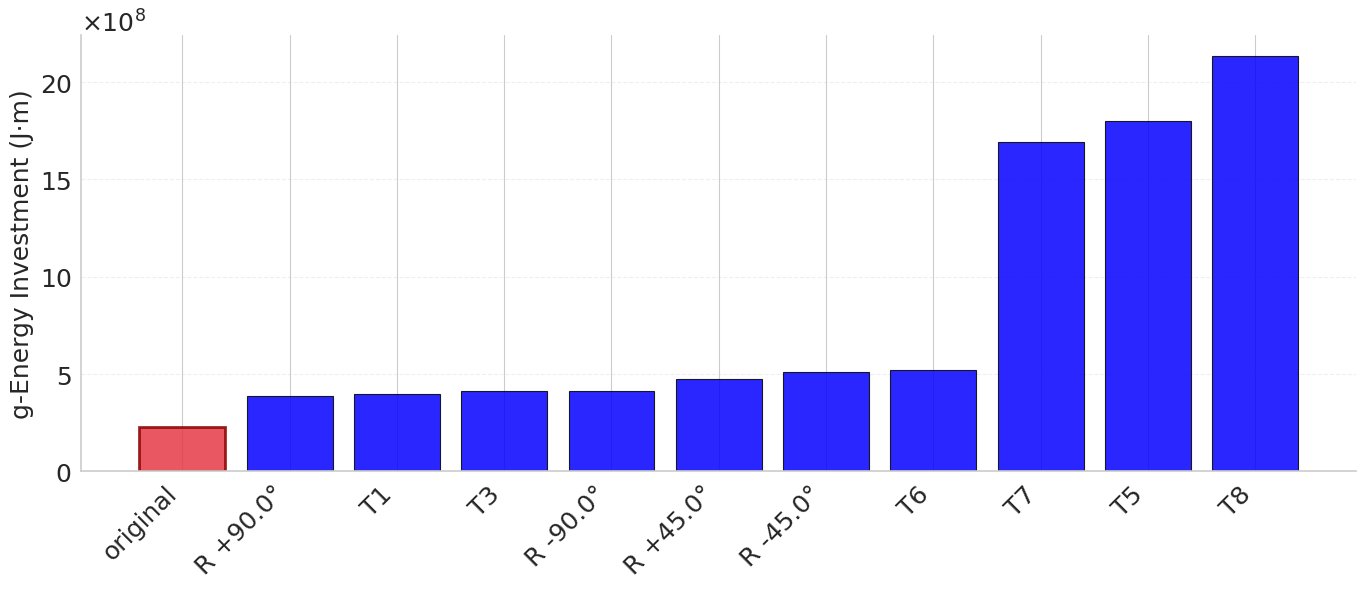


✓ Bar plot: /home/fbellisardi/code/topolity/output/combined/santiago_combined_work_comparison.png
🔍 Filtro: tutte le sorgenti (graphs + fine_grid)
File CSV trovati:
  - santiago/graphs/gravitational_work_by_variant.csv
  - santiago/graphs_fine_grid/fine_grid_gravitational_work.csv

Caricamento di 2 file CSV...

Carico: gravitational_work_by_variant.csv
  Duplicati trovati: ['original', 'rot_0', 'scale_x_1.0', 'scale_y_1.0'], mantenuto: original
  Duplicati trovati: ['translated_1', 'translated_2'], mantenuto: translated_1
  ✓ Caricati 21 record da graphs
Carico: fine_grid_gravitational_work.csv
  ✓ Caricati 101 record da graphs_fine_grid
  🔍 Rimossi 10 record di tipo "scale"

📊 Totale: 112 record da 2 file
📊 Plottando 109 punti (outlier estremi rimossi)


/tmp/ipykernel_1964015/2280207974.py:139: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df_filtered.groupby('transformation_type', group_keys=False).apply(remove_extreme_outliers).reset_index(drop=True)


Salvato PNG: /home/fbellisardi/code/topolity/output/combined/santiago_boxplot_by_transformation.png
Salvato PDF: /home/fbellisardi/code/topolity/output/combined/santiago_boxplot_by_transformation.pdf


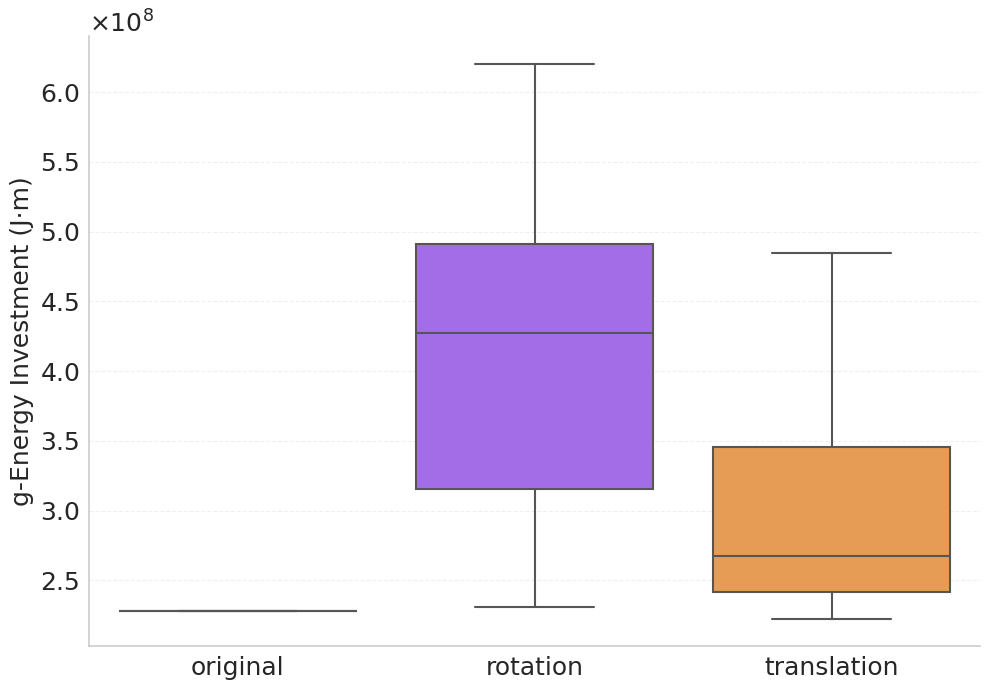

✓ Boxplot: /home/fbellisardi/code/topolity/output/combined/santiago_boxplot_by_transformation.png


In [200]:
# Grafico bar plot combinato (solo da graphs)
out_path = run_combined_plot(CITY, source_filter="graphs")
print(f'\n✓ Bar plot: {out_path}')

# Grafico boxplot per tipo trasformazione (tutte le configurazioni da graphs + fine_grid)
out_boxplot = run_boxplot(CITY, source_filter="all")
print(f'✓ Boxplot: {out_boxplot}')

🔍 Filtro attivo: solo cartelle 'graphs' (no fine_grid)
File CSV trovati:
  - santiago/graphs/gravitational_work_by_variant.csv

Caricamento di 1 file CSV...

Carico: gravitational_work_by_variant.csv
  Duplicati trovati: ['original', 'rot_0', 'scale_x_1.0', 'scale_y_1.0'], mantenuto: original
  Duplicati trovati: ['translated_1', 'translated_2'], mantenuto: translated_1
  ✓ Caricati 21 record da graphs
  🔍 Rimossi 10 record di tipo "scale"

📊 Totale: 11 record da 1 file
🔍 Filtro: tutte le sorgenti (graphs + fine_grid)
File CSV trovati:
  - santiago/graphs/gravitational_work_by_variant.csv
  - santiago/graphs_fine_grid/fine_grid_gravitational_work.csv

Caricamento di 2 file CSV...

Carico: gravitational_work_by_variant.csv
  Duplicati trovati: ['original', 'rot_0', 'scale_x_1.0', 'scale_y_1.0'], mantenuto: original
  Duplicati trovati: ['translated_1', 'translated_2'], mantenuto: translated_1
  ✓ Caricati 21 record da graphs
Carico: fine_grid_gravitational_work.csv
  ✓ Caricati 101 reco

/tmp/ipykernel_1964015/2280207974.py:250: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_box = df_box.groupby('transformation_type', group_keys=False).apply(remove_extreme_outliers).reset_index(drop=True)


Salvato PNG combinato: /home/fbellisardi/code/topolity/output/combined/santiago_combined_figure.png
Salvato PDF combinato: /home/fbellisardi/code/topolity/output/combined/santiago_combined_figure.pdf


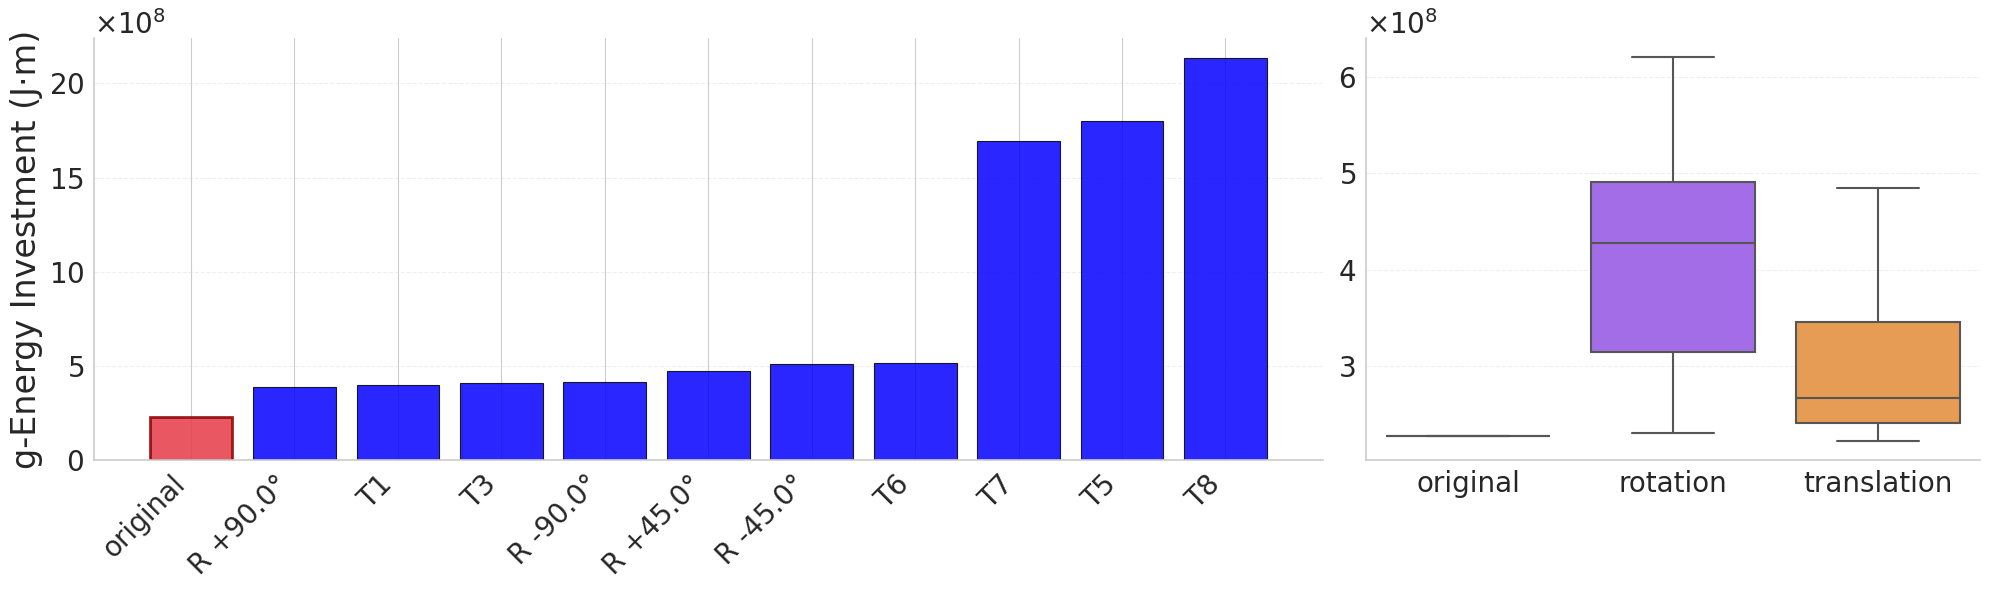

✓ Figura combinata: /home/fbellisardi/code/topolity/output/combined/santiago_combined_figure.png


In [201]:
# Grafico combinato (bar plot da graphs + boxplot da graphs + fine_grid)
out_combined = run_combined_figure(CITY)
print(f'✓ Figura combinata: {out_combined}')

In [202]:
# Verifica angoli disponibili nelle traslazioni
trans_df = df[df['transformation_type'] == 'translation'].copy()

def extract_angle(variant):
    if 'trans_' in variant.lower():
        parts = variant.split('_')
        for part in parts:
            if part.startswith('a'):
                return int(part[1:])
    return None

trans_df['angle'] = trans_df['variant'].apply(extract_angle)

print("=== ANGOLI DISPONIBILI NELLE TRASLAZIONI ===")
print(f"Totale traslazioni: {len(trans_df)}")
print(f"\nDistribuzione angoli:")
print(trans_df['angle'].value_counts().sort_index())
print(f"\nAngoli unici: {sorted(trans_df['angle'].dropna().unique())}")

# Verifica se ci sono angoli non cardinali (diversi da 0, 90, 180, 270)
cardinal_angles = {0, 90, 180, 270, 360}
all_angles = set(trans_df['angle'].dropna())
non_cardinal = all_angles - cardinal_angles

if non_cardinal:
    print(f"\n✓ Angoli NON cardinali trovati: {sorted(non_cardinal)}")
    print(f"  Numero di traslazioni con angoli casuali: {trans_df['angle'].isin(non_cardinal).sum()}")
else:
    print("\n✗ Nessun angolo non cardinale trovato (solo N/S/E/W disponibili)")

=== ANGOLI DISPONIBILI NELLE TRASLAZIONI ===
Totale traslazioni: 6

Distribuzione angoli:
Series([], Name: count, dtype: int64)

Angoli unici: []

✗ Nessun angolo non cardinale trovato (solo N/S/E/W disponibili)


In [203]:
# Verifica formato delle varianti nelle traslazioni
trans_df = df[df['transformation_type'] == 'translation'].copy()
print("=== FORMATO VARIANTI TRASLAZIONI ===")
print(f"Totale traslazioni: {len(trans_df)}")
print(f"\nVarianti trovate:")
for idx, row in trans_df.iterrows():
    print(f"  - {row['variant']}")
    
print(f"\nColonne disponibili:")
print(trans_df.columns.tolist())

=== FORMATO VARIANTI TRASLAZIONI ===
Totale traslazioni: 6

Varianti trovate:
  - translated_1
  - translated_3
  - translated_6
  - translated_7
  - translated_5
  - translated_8

Colonne disponibili:
['variant', 'work_wd', 'work_hol', 'total_work', 'city', 'source_file', 'source_folder', 'transformation_type']
